<a href="https://colab.research.google.com/github/bangjunhyuk1111/-/blob/main/%ED%9B%88%EB%A0%A8%20%EC%84%B8%ED%8A%B8%EC%99%80%20%ED%85%8C%EC%8A%A4%ED%8A%B8%20%EC%84%B8%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **훈련 세트와 테스트 세트**

비지도 학습에서 훈련 데이터를 통하여 정답을 학습한 후, 같은 데이터로 테스트를 진행할 경우 머신러닝 알고리즘을 제대로 테스트 할 수 없다.

(이 경우는 모의고사의 정답을 모두 알려주고 같은 문제를 출제하여 시험을 보는 경우)

따라서 머신러닝 알고리즘을 제대로 테스트 하기 위해서는 훈련 데이터(훈련 세트)와 테스트 데이터(테스트 세트)가 각각 달라야 한다.


In [ ]:
#생선정보 리스트
fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [ ]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)] # 하나의 리스트에 생선 데이터를 정리한다.
fish_target = [1]*35 + [0]*14 # 리스트에 들어있는 데이터들이 1에 해당하는 생선과 0에 해당하는 생선이 정렬되었음을 나타낸다.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#sklearn.neighbors: sklearn이라는 큰 패키지 안에 있는 neighbors라는 모듈(또는 서브패키지)을 가리킵니다.
#import KNeighborsClassifier: neighbors 모듈 안에 정의된 KNeighborsClassifier라는 특정 클래스(여기서는 머신러닝 모델)만 현재 코드 파일로 가져와서 사용하겠다는 뜻입니다
kn = KNeighborsClassifier()

In [ ]:
print(fish_data[4])

[29.0, 430.0]


In [ ]:
print(fish_data[2:5])

[[26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]


In [ ]:
# 인덱스 0 ~ 34 까지 입력값 훈련 세트로 사용
train_input = fish_data[:35]
# 인덱스 0 ~ 34 까지 타깃값(어떤 생선인지) 훈련세트로 사용
# 지도학습에서의 정답데이터
train_target = fish_target[:35]
# 인덱스 35부터 입력값 테스트 세트
test_input = fish_data[35:]
# 인덱스 35부터 타깃값 테스트 세트
test_target = fish_target[35:]

In [ ]:
# 인덱스 0 ~ 34 까지 입력값 훈련 세트로 사용
train_input = fish_data[:35]
# 인덱스 0 ~ 34 까지 타깃값(어떤 생선인지) 훈련세트로 사용
# 지도학습에서의 정답데이터
train_target = fish_target[:35]
# 인덱스 35부터 입력값 테스트 세트
test_input = fish_data[35:]
# 인덱스 35부터 타깃값 테스트 세트
test_target = fish_target[35:]

kn.fit(train_input, train_target) # 훈련
kn.score(test_input, test_target) # 평가

0.0

와같이 정확도가 0 이 나온 이유는 샘플링 편향 때문이다.

훈련 데이터에는 도미에 대한 데이터만 담겨있었고,

테스트 데이터에는 빙어에 대한 데이터맘 담겨있었기에 이러한 현상이 발생한 것이다.

샘플링 편향을 해결하기 위해서는 훈련 세트와 테스트 세트에 샘플이 골고루 섞여 있어야 한다.

파이썬 라이브러리인 ***넘파이***로 이 작업을 간편하게 해결할 수 있다.

# **넘파이**

배열 라이브러리

In [ ]:
import numpy as np
# 파이썬 리스트를 넘파이 배열로
input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

print(input_arr)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [ ]:
# shape속성을 이용하여 배열의 모양을 알 수 있다.
#결과값은 (샘플 수, 특성 수)
print(input_arr.shape)

(49, 2)


In [ ]:
# 이제 훈련 세트의 순서를 랜덤으로 뽑는 법을 알아보자
# 1씩 증가하는 숫자를 배열로 만든다
index = np.arange(49) #arrange(시작, 끝 값, 간격)은 시작 부터 일정 간격만큼 띄워지는 배열을 만든다
# 배열에 있는 데이터를 무작위로 섞는다
np.random.shuffle(index)
# 책과 같은 랜덤한 결과가 나오게 하기 위해 아래의 코드를 쓴다.
np.random.seed(42)
print(index)


[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [ ]:
# 넘파이의 배열 인덱싱 : 배열에서 여러 개의 인덱스를 통해 여러 개의 원소를 뽑아낼 수 있다
print("인덱스 하나 선택: ", input_arr[1]) # 인덱스 하나 선택
print("인덱스 여러개 선택: ",input_arr[[1, 3]]) # 인덱스 여러 개 선택


인덱스 하나 선택:  [ 26.3 290. ]
인덱스 여러개 선택:  [[ 26.3 290. ]
 [ 29.  363. ]]


In [ ]:
# 랜덤하게 섞은 훈련 세트와 테스트 세트
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]

test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

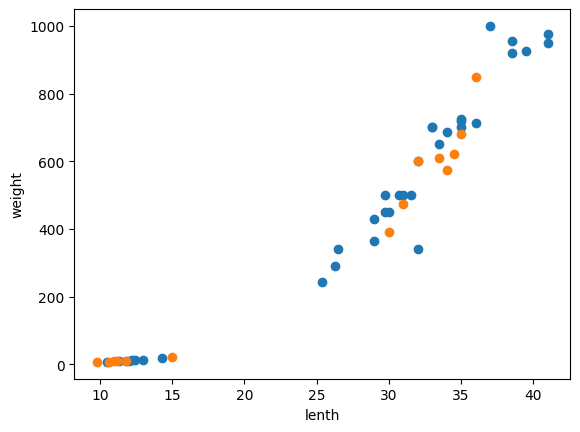

In [ ]:
# 훈련 세트와 테스트 세트에 도미와 빙어가 잘 섞였는지 확인
import matplotlib.pyplot as plt
# scatter(x좌표, y좌표) 에 점을 찍는다.
# 함수에 배열이 들어가서 여러점이 한번에 찍힌다고 생각
plt.scatter(train_input[:,0], train_input[:,1])
plt.scatter(test_input[:,0], test_input[:,1])
plt.xlabel('lenth')
plt.ylabel('weight')
plt.show()
#결과를 보니 훈련 세트, 테스트 세트에 골고루 배치되었다.

In [ ]:
# 이제 실제로 정확도 테스트를 하기위해 k-최근접 이웃 모델을 훈련하고, 테스트 해보자
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

In [ ]:
# 훈련된 모델에 테스트를 통해 얻은 결과 값(타깃값)
kn.predict(test_input)


[0 0 1 0 1 1 1 0 1 1 0 1 1 0]


In [ ]:
# 훈련된 모델에 테스트를 통해 얻은 결과 값과 실제 테스트 세트의 타깃값을 비교
test_target

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0])

훈련된 모델을 통해서 모든 테스트값이 올바르게 나왔다.